
# ⚡ Optimalizace Rezervovaného Příkonu — Průmyslový Závod (CZ)
### Reálná data · PuLP LP · Leden–Květen 2025 · BESS 5.5 MWh · FVE 450 kW AC

---

**Co tento notebook dělá:**

> Každý měsíc (Leden–Květen) máme typický týdenní profil spotřeby, FVE výroby a OTE cen
> (672 intervalů × 15 min = 7 dní). LP solver **současně optimalizuje** rezervovaný příkon
> `P_rez` i dispatch BESS tak, aby byly **celkové měsíční náklady minimální**.

---

| Sekce | Obsah |
|-------|-------|
| **1** | Matematický model — proměnné, účelová funkce, omezení |
| **2** | Načtení dat z Excel (reálné profily) |
| **3** | LP model (PuLP) — definice a řešení pro každý měsíc |
| **4** | Výsledky — tabulky a srovnání s Excel benchmarkem |
| **5** | Vizualizace — seaborn dashboardy pro každý měsíc |
| **6** | Srovnání měsíců — analýza úspor a vlivu FVE/BESS |



## 1. Matematický model

### 1.1 Proměnné rozhodování

| Symbol | Jednotka | Popis |
|--------|----------|-------|
| $P_{rez}$ | kW | **Rezervovaný příkon** — hlavní rozhodovací proměnná |
| $P_{peak}$ | kW | Skutečný týdenní peak odběru ze sítě |
| $P_{grid,t}$ | kW | Odběr ze sítě v intervalu $t$ |
| $P_{ch,t}$ | kW | Výkon nabíjení BESS v intervalu $t$ |
| $P_{dch,t}$ | kW | Výkon vybíjení BESS v intervalu $t$ |

### 1.2 Parametry (konstanty)

| Symbol | Hodnota | Jednotka | Popis |
|--------|---------|----------|-------|
| $E_{BESS}$ | 5 500 | kWh | Kapacita baterie |
| $P_{max}$ | 2 750 | kW | Max nabíjení/vybíjení (C-rate = 0.5) |
| $\eta_{ch}, \eta_{dch}$ | 0.95 | — | Účinnost nabíjení / vybíjení |
| $SOC_{min}, SOC_{max}$ | 0.1 / 0.9 | pu | Limity stavu nabití |
| $c_{rez}$ | 350 | CZK/kW/měs | Cena za rezervovaný příkon |
| $c_{pen}$ | 300 × 2.5 | CZK/kW/měs | Pokuta za překročení $P_{rez}$ |
| $c_{dist}$ | 87 | CZK/MWh | Distribuční energetická složka |
| $c_{deg}$ | 80 | CZK/MWh | Degradační náklad BESS |
| $\Delta t$ | 0.25 | h | Délka intervalu (15 min) |
| $T$ | 672 | — | Počet intervalů (7 dní) |

### 1.3 Účelová funkce

Minimalizujeme **celkové týdenní náklady** (přepočtené na měsíc přes `weekly_factor`):

$$\min \underbrace{c_{rez} \cdot P_{rez} \cdot f_w}_{\text{rezervace}} + \sum_{t=0}^{T-1} \left[ \underbrace{\frac{(\lambda_t + c_{dist}) \cdot P_{grid,t} \cdot \Delta t}{1000}}_{\text{energie ze sítě}} + \underbrace{\frac{c_{deg} \cdot (P_{ch,t} + P_{dch,t}) \cdot \Delta t}{1000}}_{\text{degradace BESS}} \right]$$

kde $f_w = \frac{7}{30.44}$ je týdenní faktor pro měsíční odhad.

> **Poznámka:** Pokuta za překročení `P_rez` je modelována jako tvrdé omezení
> $P_{grid,t} \leq P_{rez}$ — solver ji nesmí překročit. Alternativně: soft constraint.

### 1.4 Omezení

$$\text{(C1 — bilance výkonu)} \quad P_{grid,t} + P_{dch,t} - P_{ch,t} = \underbrace{L_t - G_t}_{net_t} \qquad \forall t$$

$$\text{(C2 — rezervace)} \quad P_{grid,t} \leq P_{rez} \qquad \forall t$$

$$\text{(C3 — SOC rekurence)} \quad SOC_{t+1} = SOC_t + \eta_{ch} \cdot P_{ch,t} \cdot \Delta t - \frac{P_{dch,t}}{\eta_{dch}} \cdot \Delta t$$

$$\text{(C4 — SOC limity)} \quad SOC_{min} \cdot E_{BESS} \leq SOC_t \leq SOC_{max} \cdot E_{BESS} \qquad \forall t$$

$$\text{(C5 — P limity)} \quad 0 \leq P_{ch,t} \leq P_{max}, \quad 0 \leq P_{dch,t} \leq P_{max} \qquad \forall t$$

$$\text{(C6 — denní reset SOC)} \quad SOC_{d \cdot 96} = 0.5 \cdot E_{BESS} \qquad \forall d \in \{0,1,\ldots,6\}$$

$$\text{(C7 — P\_rez rozsah)} \quad P_{rez,min} \leq P_{rez} \leq P_{grid,max}$$

> **C6** je klíčové: BESS se každý den resetuje na 50 % — zabraňuje tomu, aby solver
> "spotřeboval" energii nabitou v pondělí a nikdy ji nevrátil.


## 2. Načtení dat

In [1]:
# ── Knihovny ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pulp
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)

print("Verze knihoven:")
print(f"  numpy   {np.__version__}")
print(f"  pandas  {pd.__version__}")
print(f"  pulp    {pulp.__version__}")
print(f"  seaborn {sns.__version__}")


Verze knihoven:
  numpy   2.4.2
  pandas  3.0.1
  pulp    3.3.0
  seaborn 0.13.2


### 2.1 Parametry z listu Assumptions

In [2]:
# ── Všechny parametry z Guzu_Real_fixed_50.xlsx / Assumptions ─────────────
# (Přepsány přímo — pro přehlednost a reprodukovatelnost)

BESS_cap   = 5_500      # kWh  — kapacita baterie
P_max      = 2_750      # kW   — max nabíjení = max vybíjení (C-rate 0.5)
eta_ch     = 0.95       # —    — účinnost nabíjení
eta_dch    = 0.95       # —    — účinnost vybíjení
SOC_min_pu = 0.10       # pu   — minimální SoC
SOC_max_pu = 0.90       # pu   — maximální SoC
SOC_init_pu= 0.50       # pu   — počáteční SoC (každý den)

SOC_min    = SOC_min_pu * BESS_cap   # kWh = 550
SOC_max    = SOC_max_pu * BESS_cap   # kWh = 4950
SOC_init   = SOC_init_pu * BESS_cap  # kWh = 2750

FVE_dc_kw  = 500        # kW   — peak DC výkon FVE
FVE_ac_lim = 450        # kW   — limit střídače AC
FVE_pr     = 0.82       # pu   — performance ratio

P_grid_max = 4_000      # kW   — tvrdý limit připojky
dt         = 0.25       # h    — krok 15 min
T          = 672        # —    — 7 dní × 96 intervalů

c_rez      = 350        # CZK/kW/měs — cena za rezervaci
c_pen_unit = 300        # CZK/kW/měs — pokuta za překročení
c_pen_mult = 2.5        # —           — multiplikátor pokuty
c_dist     = 87         # CZK/MWh    — distribuční složka
c_deg      = 80         # CZK/MWh    — degradace BESS

P_rez_min  = 500        # kW   — smluvní minimum
P_rez_max  = P_grid_max # kW

days_in_month = 30.44   # průměr
weekly_factor = 7 / days_in_month   # přepočet týden → měsíc

# Excel benchmark (z listu Assumptions — vyplněné hodnoty)
EXCEL_BENCHMARK = {
    "Jan": 1810.97,
    "Feb": 1955.52,
    "Mar": 2364.00,
    "Apr": None,
    "May": None,
}

print("✓ Parametry načteny")
print(f"  BESS: {BESS_cap} kWh  |  P_max: {P_max} kW")
print(f"  SOC: [{SOC_min:.0f}, {SOC_max:.0f}] kWh  |  init: {SOC_init:.0f} kWh")
print(f"  c_rez: {c_rez} CZK/kW/měs  |  c_dist: {c_dist} CZK/MWh")
print(f"  T: {T} intervalů = {T*dt:.0f} h = 7 dní")


✓ Parametry načteny
  BESS: 5500 kWh  |  P_max: 2750 kW
  SOC: [550, 4950] kWh  |  init: 2750 kWh
  c_rez: 350 CZK/kW/měs  |  c_dist: 87 CZK/MWh
  T: 672 intervalů = 168 h = 7 dní


### 2.2 Načtení týdenních profilů z Excel

In [3]:
PROFILES_FILE = "Profiles_15min_v2.xlsx"

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May"]
SHEET_MAP = {
    "Jan": "TypWeek_Jan",
    "Feb": "TypWeek_Feb",
    "Mar": "TypWeek_Mar",
    "Apr": "TypWeek_Apr",
    "May": "TypWeek_May",
}

def load_week_profile(month: str) -> pd.DataFrame:
    """
    Načte typický týdenní profil z TypWeek_* listu.

    Vrátí DataFrame s 672 řádky a sloupci:
      time_str, dow, interval,
      load_kw, fve_kw, ote_czk_mwh, net_kw

    Vstupní data jsou v kWh/interval → převod na kW: / dt (÷ 0.25)
    """
    sheet = SHEET_MAP[month]
    # Řádek 0 = titulek, řádek 1 = hlavičky, data od řádku 2
    df_raw = pd.read_excel(
        PROFILES_FILE, sheet_name=sheet, header=None, skiprows=2
    )
    df_raw.columns = ["day_name", "dow", "interval", "time_str",
                      "consumption_kwh", "fve_kwh", "ote_czk_mwh"]

    # kWh/15min → kW
    df = pd.DataFrame({
        "time_str":     df_raw["time_str"].astype(str),
        "dow":          df_raw["dow"].astype(int),
        "interval":     df_raw["interval"].astype(int),
        "load_kw":      df_raw["consumption_kwh"] / dt,    # kWh → kW
        "fve_kw":       (df_raw["fve_kwh"] / dt).clip(upper=450),  # kWh→kW, capped at AC inverter limit
        "ote_czk_mwh":  df_raw["ote_czk_mwh"].astype(float),
    })

    # Čistá potřeba (pozitivní = odběr, negativní = přebytek FVE)
    df["net_kw"] = df["load_kw"] - df["fve_kw"]

    # Časový index v rámci týdne (0..671)
    df.index = range(len(df))
    return df

# Načti všechny měsíce
profiles = {}
for m in MONTHS:
    profiles[m] = load_week_profile(m)
    print(f"  {m}: {len(profiles[m])} intervalů  |  "
          f"load max={profiles[m]['load_kw'].max():,.0f} kW  "
          f"avg={profiles[m]['load_kw'].mean():,.0f} kW  |  "
          f"FVE max={profiles[m]['fve_kw'].max():,.1f} kW  |  "
          f"OTE avg={profiles[m]['ote_czk_mwh'].mean():,.0f} CZK/MWh")

print("\n✓ Všechny profily načteny")


  Jan: 672 intervalů  |  load max=2,371 kW  avg=1,482 kW  |  FVE max=417.7 kW  |  OTE avg=3,227 CZK/MWh
  Feb: 672 intervalů  |  load max=2,628 kW  avg=1,712 kW  |  FVE max=450.0 kW  |  OTE avg=3,327 CZK/MWh


  Mar: 672 intervalů  |  load max=2,291 kW  avg=1,573 kW  |  FVE max=450.0 kW  |  OTE avg=2,518 CZK/MWh


  Apr: 672 intervalů  |  load max=2,276 kW  avg=1,472 kW  |  FVE max=450.0 kW  |  OTE avg=1,972 CZK/MWh
  May: 672 intervalů  |  load max=2,332 kW  avg=1,429 kW  |  FVE max=450.0 kW  |  OTE avg=1,848 CZK/MWh

✓ Všechny profily načteny


### 2.3 Přehled vstupních dat

In [4]:
# Srovnávací tabulka vstupních dat po měsících
summary_rows = []
for m in MONTHS:
    df = profiles[m]
    summary_rows.append({
        "Měsíc":            m,
        "Spotřeba avg (kW)": f"{df['load_kw'].mean():,.1f}",
        "Spotřeba max (kW)": f"{df['load_kw'].max():,.1f}",
        "FVE avg (kW)":      f"{df['fve_kw'].mean():,.1f}",
        "FVE max (kW)":      f"{df['fve_kw'].max():,.1f}",
        "Čistá avg (kW)":    f"{df['net_kw'].mean():,.1f}",
        "Čistá max (kW)":    f"{df['net_kw'].max():,.1f}",
        "OTE avg (CZK/MWh)": f"{df['ote_czk_mwh'].mean():,.0f}",
        "OTE max (CZK/MWh)": f"{df['ote_czk_mwh'].max():,.0f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Měsíc")
print("Vstupní profily — týdenní statistika:")
print(summary_df.to_string())


Vstupní profily — týdenní statistika:
      Spotřeba avg (kW) Spotřeba max (kW) FVE avg (kW) FVE max (kW) Čistá avg (kW) Čistá max (kW) OTE avg (CZK/MWh) OTE max (CZK/MWh)
Měsíc                                                                                                                                
Jan             1,482.0           2,371.1         56.5        417.7        1,425.5        2,337.7             3,227             6,369
Feb             1,711.6           2,628.4        119.7        450.0        1,591.9        2,564.7             3,327             5,215
Mar             1,573.3           2,291.2        158.9        450.0        1,414.4        2,105.1             2,518             4,745
Apr             1,472.4           2,275.8        194.5        450.0        1,277.9        2,208.5             1,972             4,501
May             1,428.7           2,332.1        211.1        450.0        1,217.6        2,202.5             1,848             5,129



## 3. LP Model (PuLP)

### 3.1 Definice modelu

Funkce `solve_week()` přijme profily jednoho měsíce a vrátí optimální `P_rez`
a celý dispatch plán. Komentáře odkazují na omezení C1–C7 z matematického modelu výše.


In [5]:
def solve_week(df: pd.DataFrame, month_name: str = "") -> dict:
    """
    LP optimalizace týdenního dispatche.

    Vstupy:
      df — DataFrame se sloupci: load_kw, fve_kw, net_kw, ote_czk_mwh
           672 řádků (7 dní × 96 intervalů po 15 min)

    Výstup: dict s optimálními hodnotami a celým dispatch profilem
    """
    T_local = len(df)  # = 672
    OTE  = df["ote_czk_mwh"].values.astype(float)
    net  = df["net_kw"].values.astype(float)       # L - G [kW]
    load = df["load_kw"].values.astype(float)
    fve  = df["fve_kw"].values.astype(float)

    # ── Vytvoření LP problému ──────────────────────────────────────────────
    prob = pulp.LpProblem(f"WeeklyDispatch_{month_name}", pulp.LpMinimize)

    # ── Rozhodovací proměnné ───────────────────────────────────────────────

    # P_rez — rezervovaný příkon [kW] (C7: bounded)
    P_rez = pulp.LpVariable("P_rez", lowBound=P_rez_min, upBound=P_rez_max)

    # P_grid[t] — odběr ze sítě v každém intervalu [kW]
    P_grid = [pulp.LpVariable(f"Pg_{t}", 0, P_grid_max) for t in range(T_local)]

    # P_ch[t], P_dch[t] — nabíjení / vybíjení BESS [kW]
    P_ch  = [pulp.LpVariable(f"Pc_{t}", 0, P_max) for t in range(T_local)]
    P_dch = [pulp.LpVariable(f"Pd_{t}", 0, P_max) for t in range(T_local)]

    # ── SOC rekurence ──────────────────────────────────────────────────────
    # SOC je lineární výraz (ne DV) — solver ho "vidí" přes P_ch, P_dch
    # C6: denní reset — každý den začíná od SOC_init
    SOC = [None] * (T_local + 1)

    for d in range(7):               # 7 dní
        t0 = d * 96                  # začátek dne (interval 0, 96, 192 ...)
        SOC[t0] = SOC_init           # C6: reset na 50 % kapacity

        for t in range(t0, t0 + 96):
            # C3: SOC_{t+1} = SOC_t + eta_ch * P_ch * dt - P_dch/eta_dch * dt
            SOC[t + 1] = (SOC[t]
                          + eta_ch  * P_ch[t]  * dt
                          - (1 / eta_dch) * P_dch[t] * dt)

    # ── Účelová funkce ─────────────────────────────────────────────────────
    # Cena za rezervaci (měsíční, přepočteno přes weekly_factor)
    cost_rez = c_rez * P_rez * weekly_factor

    # Cena za energii ze sítě (OTE + distribuce) + degradace BESS
    cost_ops = pulp.lpSum(
        (OTE[t] + c_dist) * P_grid[t] * dt / 1000          # CZK (energie)
        + c_deg * (P_ch[t] + P_dch[t]) * dt / 1000         # CZK (degradace)
        for t in range(T_local)
    )

    prob += cost_rez + cost_ops   # minimize total

    # ── Omezení ───────────────────────────────────────────────────────────
    for t in range(T_local):
        # C1: bilance výkonu — sít + vybití - nabití = čistá potřeba
        prob += P_grid[t] + P_dch[t] - P_ch[t] == net[t]

        # C2: P_grid nepřekročí rezervovaný příkon (tvrdé omezení = peak shaving)
        prob += P_grid[t] <= P_rez

        # C4: SOC limity
        prob += SOC[t + 1] >= SOC_min
        prob += SOC[t + 1] <= SOC_max

    # C7 je zajištěno bounds na P_rez (lowBound, upBound výše)

    # ── Řešení ────────────────────────────────────────────────────────────
    solver = pulp.GLPK(msg=False)
    status = prob.solve(solver)

    if pulp.LpStatus[status] not in ("Optimal", "Feasible"):
        return {"status": pulp.LpStatus[status], "month": month_name}

    # ── Extrakce výsledků ──────────────────────────────────────────────────
    p_rez_val  = pulp.value(P_rez)
    total_cost = pulp.value(prob.objective)

    pg_arr  = np.array([pulp.value(P_grid[t]) for t in range(T_local)])
    pch_arr = np.array([pulp.value(P_ch[t])   for t in range(T_local)])
    pdc_arr = np.array([pulp.value(P_dch[t])  for t in range(T_local)])

    # Rekonstrukce SOC po dávkách
    soc_arr = np.zeros(T_local)
    for d in range(7):
        t0 = d * 96
        soc_d = SOC_init
        for t in range(t0, t0 + 96):
            soc_arr[t] = soc_d
            soc_d = (soc_d
                     + eta_ch * pch_arr[t] * dt
                     - pdc_arr[t] / eta_dch * dt)

    # Náklady po složkách
    cost_rez_val  = c_rez * p_rez_val * weekly_factor
    cost_ene_val  = float(np.sum((OTE + c_dist) * pg_arr * dt / 1000))
    cost_deg_val  = float(np.sum(c_deg * (pch_arr + pdc_arr) * dt / 1000))

    return {
        "month":        month_name,
        "status":       pulp.LpStatus[status],
        "P_rez_kw":     p_rez_val,
        "total_czk":    total_cost,
        "cost_rez":     cost_rez_val,
        "cost_energy":  cost_ene_val,
        "cost_deg":     cost_deg_val,
        "monthly_czk":  total_cost / weekly_factor,   # přepočet na plný měsíc
        # Časové řady (arrays)
        "P_grid":  pg_arr,
        "P_ch":    pch_arr,
        "P_dch":   pdc_arr,
        "SOC":     soc_arr,
        "load":    load,
        "fve":     fve,
        "net":     net,
        "OTE":     OTE,
        "df":      df,
    }

print("✓ Funkce solve_week() definována")


✓ Funkce solve_week() definována


### 3.2 Řešení pro každý měsíc

In [6]:
results = {}

print(f"{'Měsíc':>6}  {'Status':>8}  {'P_rez (kW)':>12}  {'Týden (CZK)':>13}  "
      f"{'Měsíc est. (CZK)':>18}  {'Excel bench':>12}  {'Δ (kW)':>8}")
print("─" * 90)

for m in MONTHS:
    res = solve_week(profiles[m], month_name=m)
    results[m] = res

    bench = EXCEL_BENCHMARK.get(m)
    delta = f"{res['P_rez_kw'] - bench:+.1f}" if bench else "  n/a"

    print(f"  {m:>4}  {res['status']:>8}  {res['P_rez_kw']:>12,.1f}  "
          f"{res['total_czk']:>13,.0f}  {res['monthly_czk']:>18,.0f}  "
          f"{str(bench or '—'):>12}  {delta:>8}")

print("\n✓ Všechny měsíce optimalizovány")
print("  Δ = náš výsledek minus Excel benchmark (+ = vyšší rezervace)")


 Měsíc    Status    P_rez (kW)    Týden (CZK)    Měsíc est. (CZK)   Excel bench    Δ (kW)
──────────────────────────────────────────────────────────────────────────────────────────


   Jan   Optimal       1,732.0        865,675           3,764,449       1810.97     -79.0


   Feb   Optimal       1,818.3        995,036           4,326,984       1955.52    -137.2


   Mar   Optimal       1,740.6        676,522           2,941,905        2364.0    -623.4


   Apr   Optimal       1,683.6        508,600           2,211,685             —       n/a


   May   Optimal       1,584.8        458,772           1,995,002             —       n/a

✓ Všechny měsíce optimalizovány
  Δ = náš výsledek minus Excel benchmark (+ = vyšší rezervace)


### 3.3 Detailní tabulka výsledků

In [7]:
rows = []
for m in MONTHS:
    r = results[m]
    bench = EXCEL_BENCHMARK.get(m)
    rows.append({
        "Měsíc":              m,
        "P_rez* (kW)":        f"{r['P_rez_kw']:,.1f}",
        "Excel bench (kW)":   f"{bench:,.1f}" if bench else "—",
        "Cena rezervace (CZK)": f"{r['cost_rez']:,.0f}",
        "Cena energie (CZK)":   f"{r['cost_energy']:,.0f}",
        "Degradace BESS (CZK)": f"{r['cost_deg']:,.0f}",
        "Týden celkem (CZK)":   f"{r['total_czk']:,.0f}",
        "Měsíc est. (CZK)":     f"{r['monthly_czk']:,.0f}",
        "P_grid max (kW)":       f"{r['P_grid'].max():,.1f}",
        "BESS přetoky (MWh)":    f"{(r['P_ch'].sum()*dt/1000):,.2f}",
    })

res_df = pd.DataFrame(rows).set_index("Měsíc")
print("Výsledky optimalizace — Leden až Květen 2025:")
print(res_df.to_string())

# Roční projekce (5 měsíců → extrapolace)
total_monthly_avg = np.mean([results[m]["monthly_czk"] for m in MONTHS])
print(f"\nPrůměrný měsíční náklad (Leden–Květen): {total_monthly_avg:,.0f} CZK")
print(f"Roční odhad (×12):                       {total_monthly_avg*12:,.0f} CZK")


Výsledky optimalizace — Leden až Květen 2025:
      P_rez* (kW) Excel bench (kW) Cena rezervace (CZK) Cena energie (CZK) Degradace BESS (CZK) Týden celkem (CZK) Měsíc est. (CZK) P_grid max (kW) BESS přetoky (MWh)
Měsíc                                                                                                                                                                 
Jan       1,732.0          1,811.0              139,402            722,338                3,935            865,675        3,764,449         1,732.0              16.99
Feb       1,818.3          1,955.5              146,349            844,450                4,237            995,036        4,326,984         1,818.3              18.84
Mar       1,740.6          2,364.0              140,098            530,636                5,789            676,522        2,941,905         1,740.6              29.09
Apr       1,683.6                —              135,508            366,754                6,339            508,600     

## 4. Vizualizace výsledků

In [8]:
# ── Globální seaborn téma ─────────────────────────────────────────────────
D = {
    "bg":     "#0d1117",   "panel":  "#161b22",   "grid":   "#30363d",
    "text":   "#e6edf3",   "sub":    "#8b949e",
    "load":   "#ef9a9a",   "fve":    "#ffd54f",   "net":    "#80cbc4",
    "grid_p": "#4fc3f7",   "bess":   "#a78bfa",   "soc":    "#69db7c",
    "ote":    "#fb923c",   "rez":    "#f472b6",    "ch":     "#34d399",
    "dch":    "#f87171",
}

sns.set_theme(style="darkgrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor":   D["bg"],    "axes.facecolor":   D["panel"],
    "axes.edgecolor":     D["grid"],  "axes.labelcolor":  D["text"],
    "axes.titlecolor":    D["text"],  "xtick.color":      D["sub"],
    "ytick.color":        D["sub"],   "grid.color":       D["grid"],
    "grid.linewidth":     0.5,        "text.color":       D["text"],
    "legend.facecolor":   D["panel"], "legend.edgecolor": D["grid"],
    "legend.labelcolor":  D["text"],  "axes.spines.top":  False,
    "axes.spines.right":  False,
})

# Pomocné funkce
DAYS = ["Po","Út","St","Čt","Pá","So","Ne"]

def day_ticks(ax, T_local=672):
    """Přidá vertikální čáry a labely dní na osu X."""
    for d in range(7):
        ax.axvline(d * 96, color=D["grid"], linewidth=1.0, alpha=0.7)
    ax.set_xticks([d * 96 + 48 for d in range(7)])
    ax.set_xticklabels(DAYS, fontsize=9)

def style(ax, title, ylabel, xlabel=""):
    ax.set_title(title, fontweight="bold", fontsize=10, pad=8)
    ax.set_ylabel(ylabel, fontsize=9)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)

print("✓ Vizualizační téma nastaveno")


✓ Vizualizační téma nastaveno


### 4.1 Týdenní dispatch dashboard — každý měsíc

  ✓ Uloženo: dispatch_Jan.png


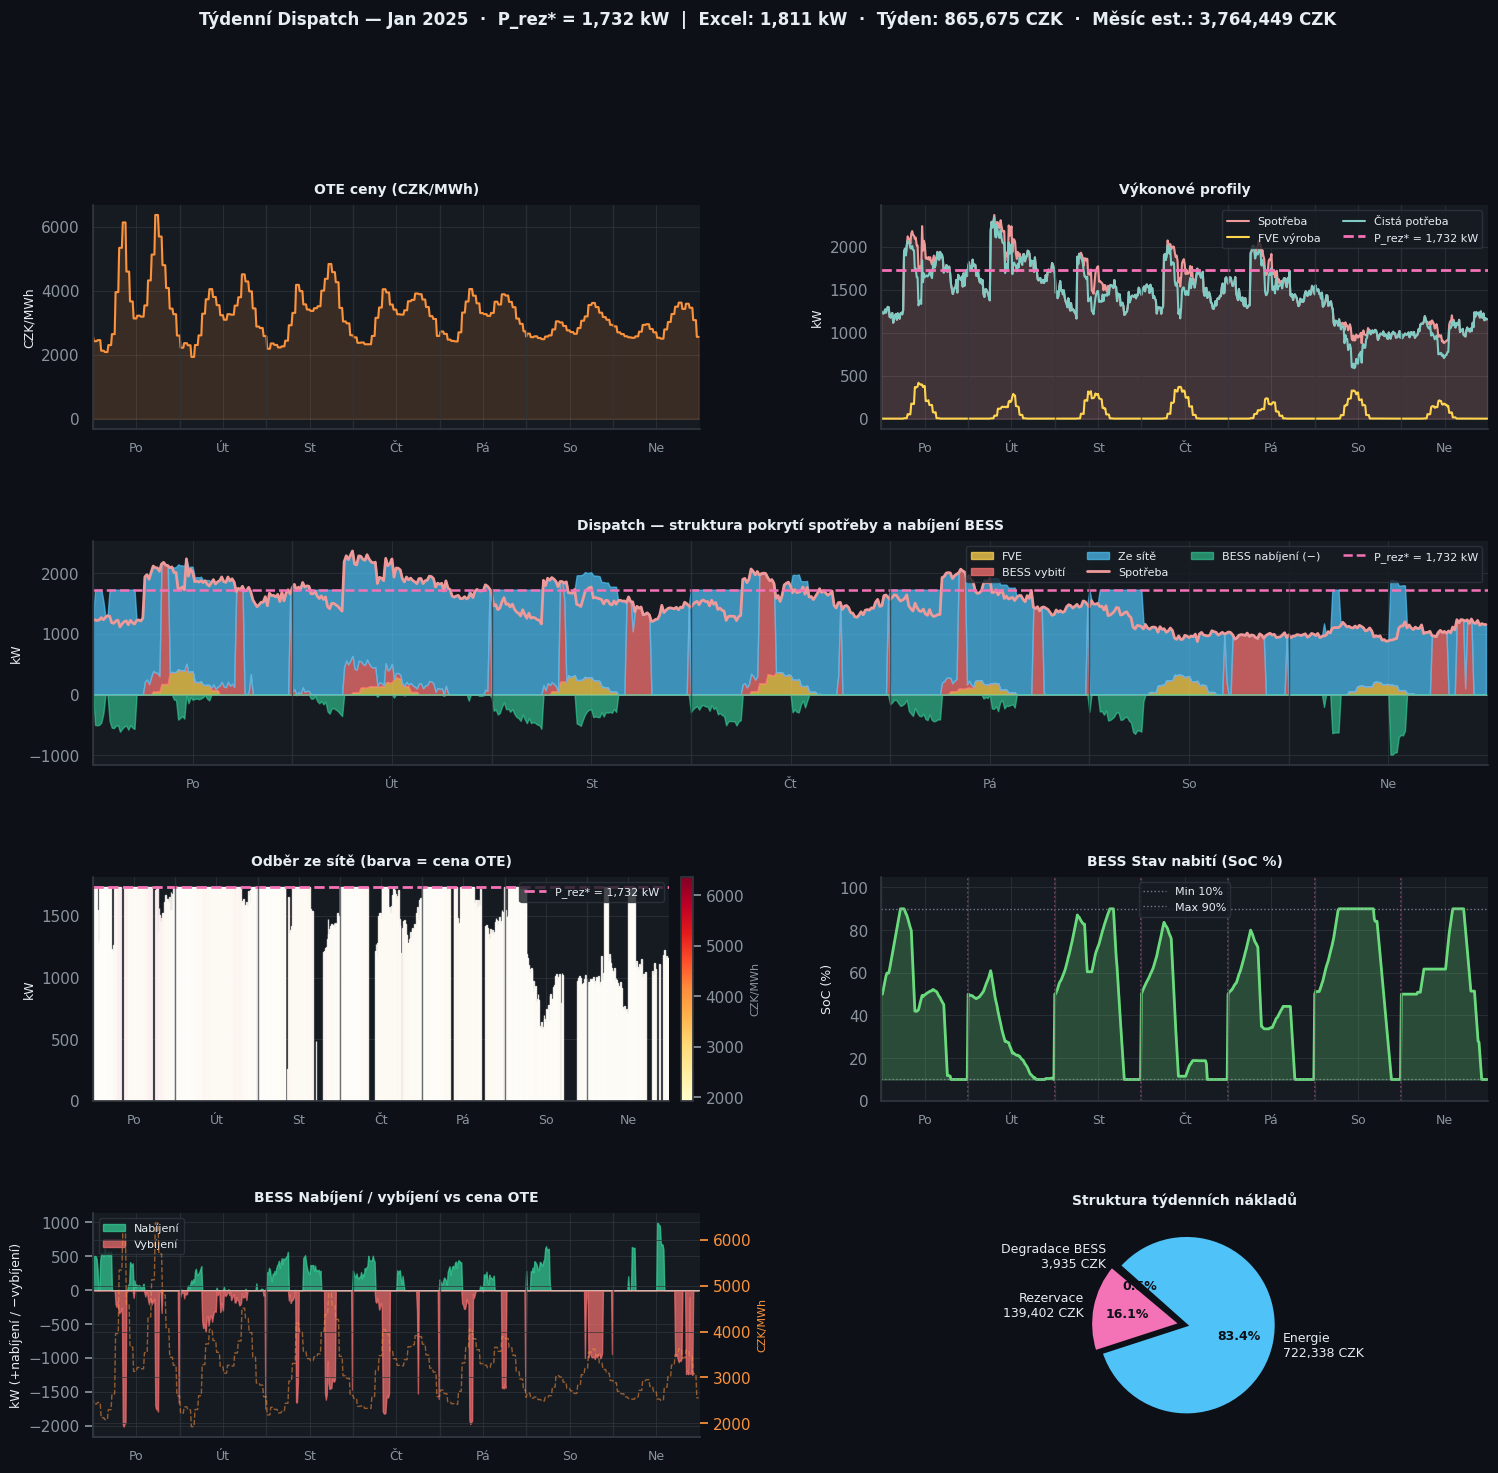

  ✓ Uloženo: dispatch_Feb.png


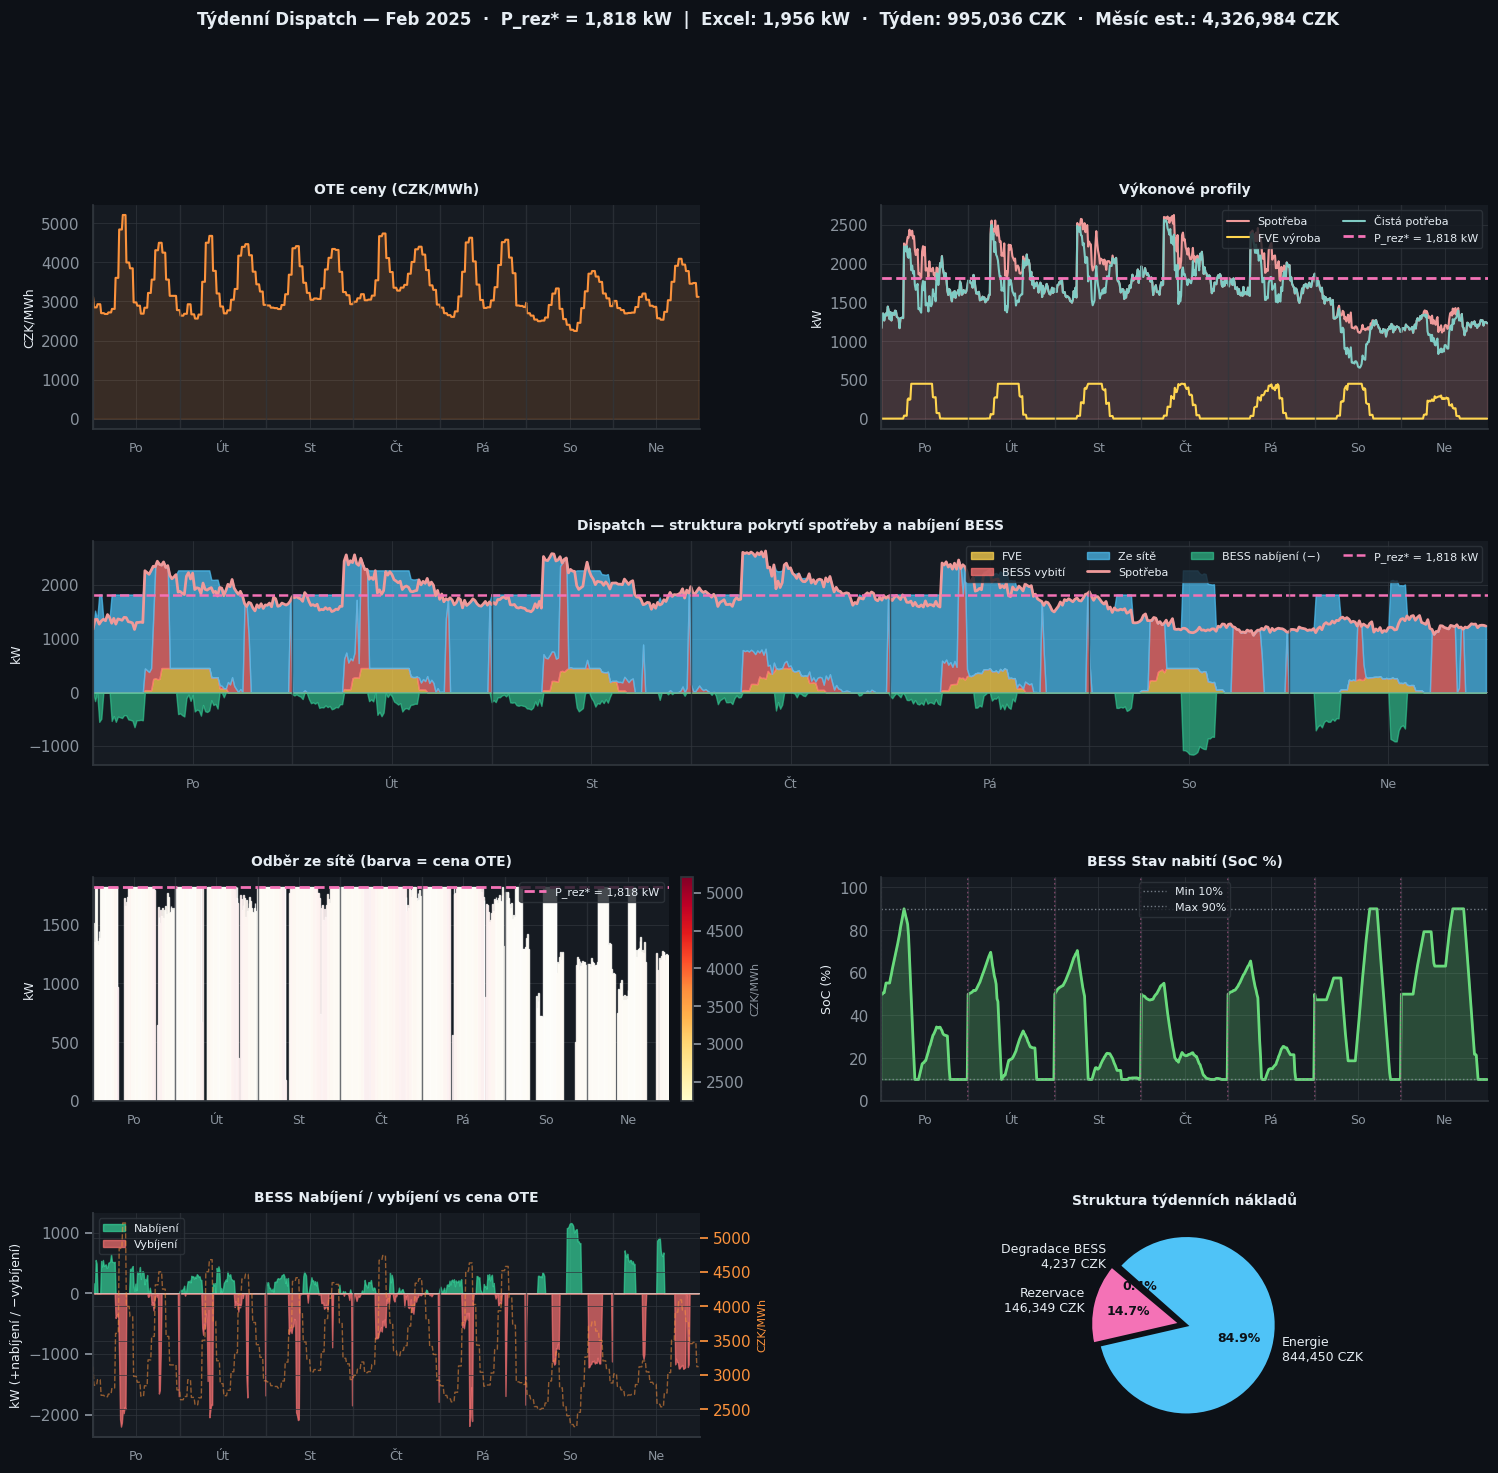

  ✓ Uloženo: dispatch_Mar.png


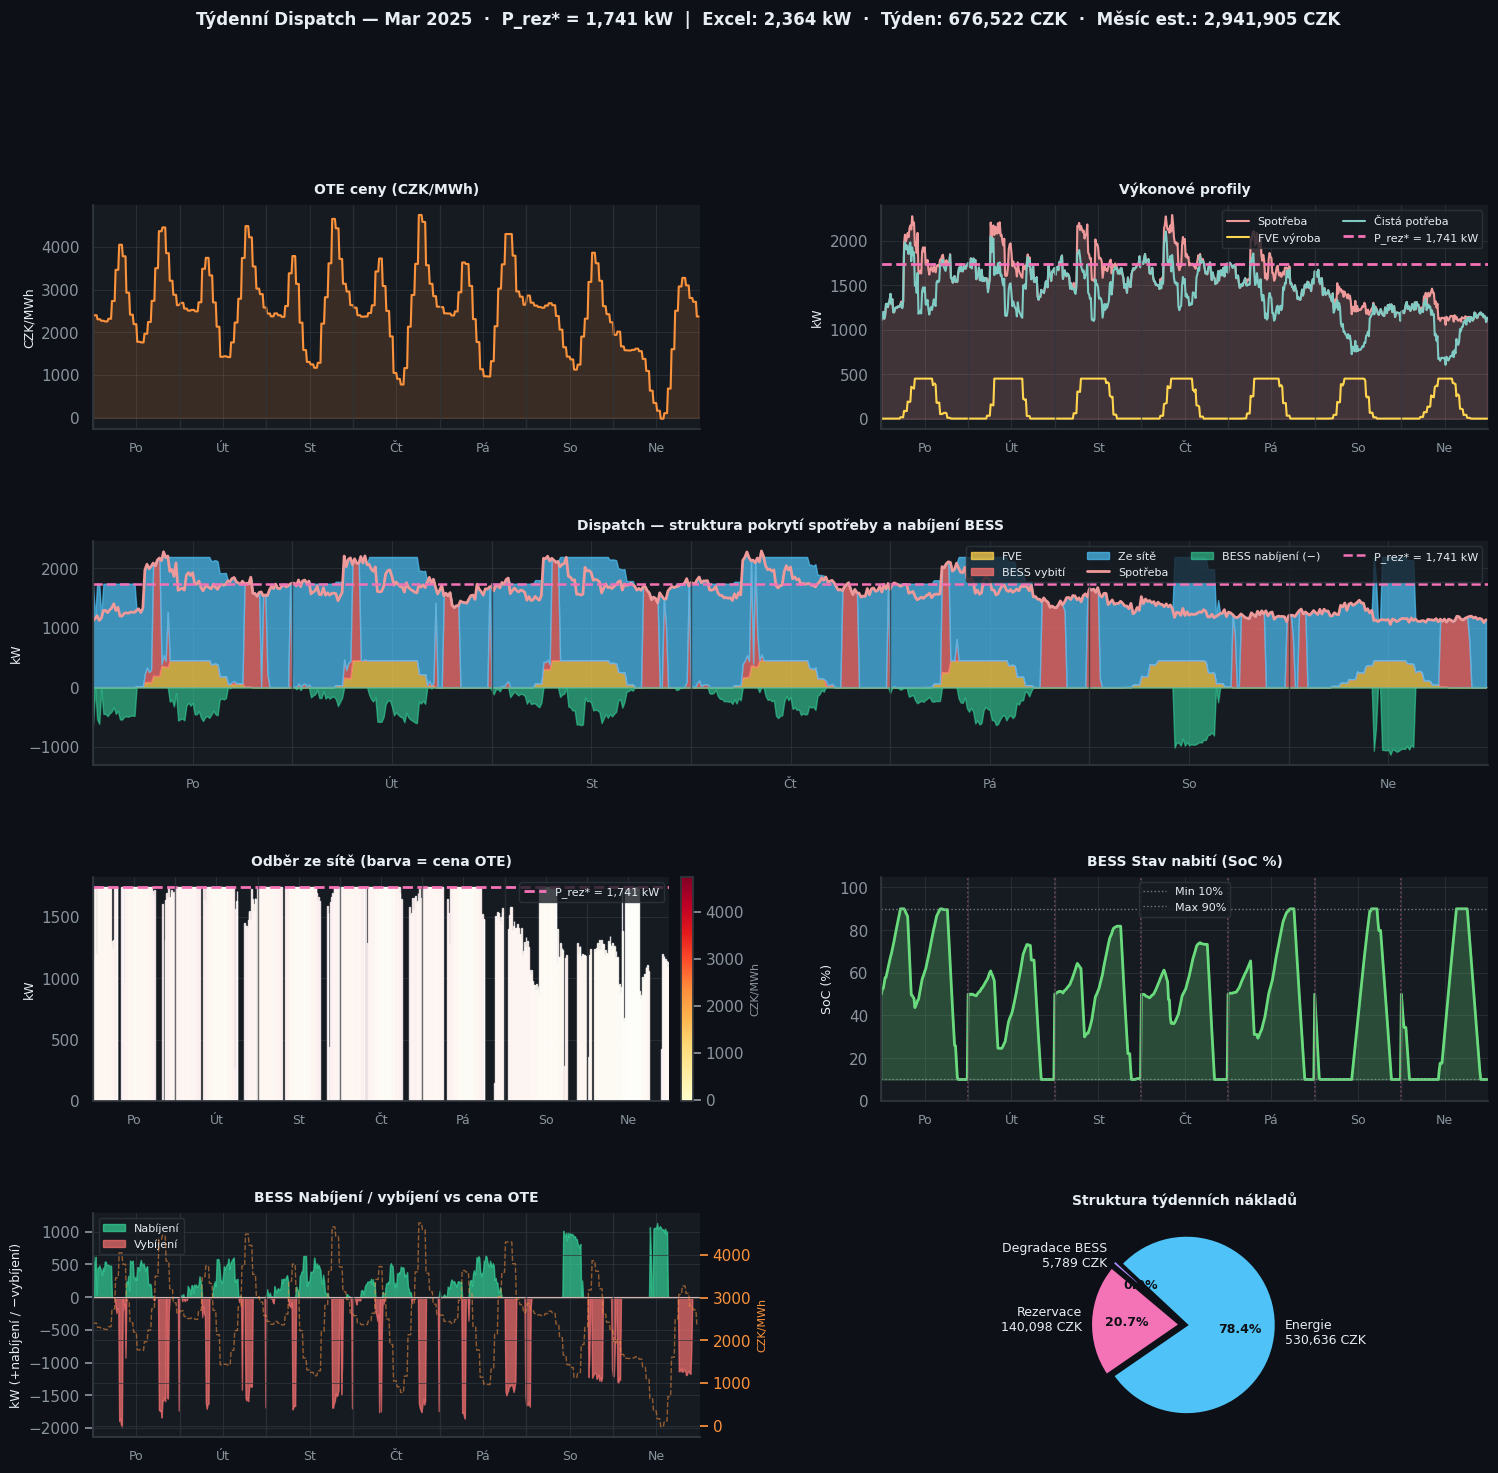

  ✓ Uloženo: dispatch_Apr.png


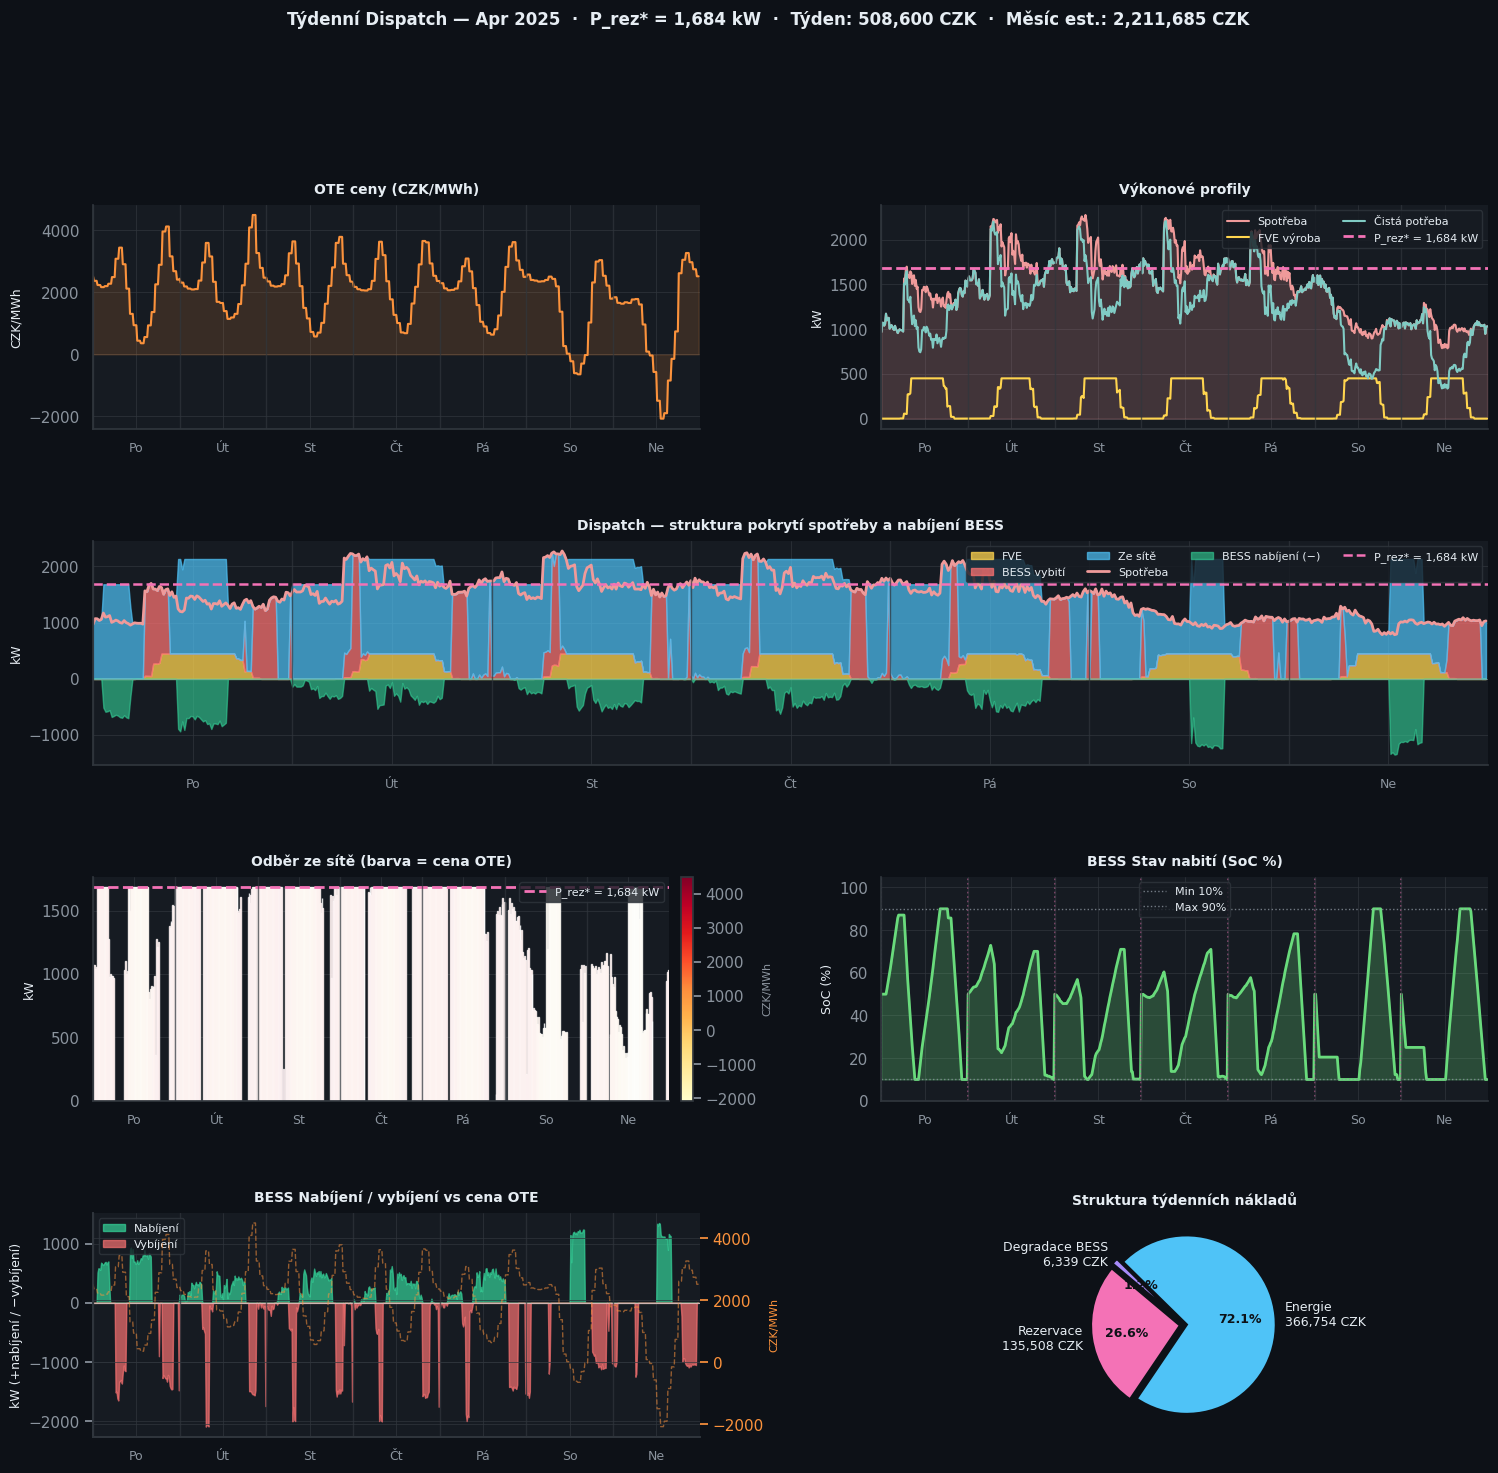

  ✓ Uloženo: dispatch_May.png


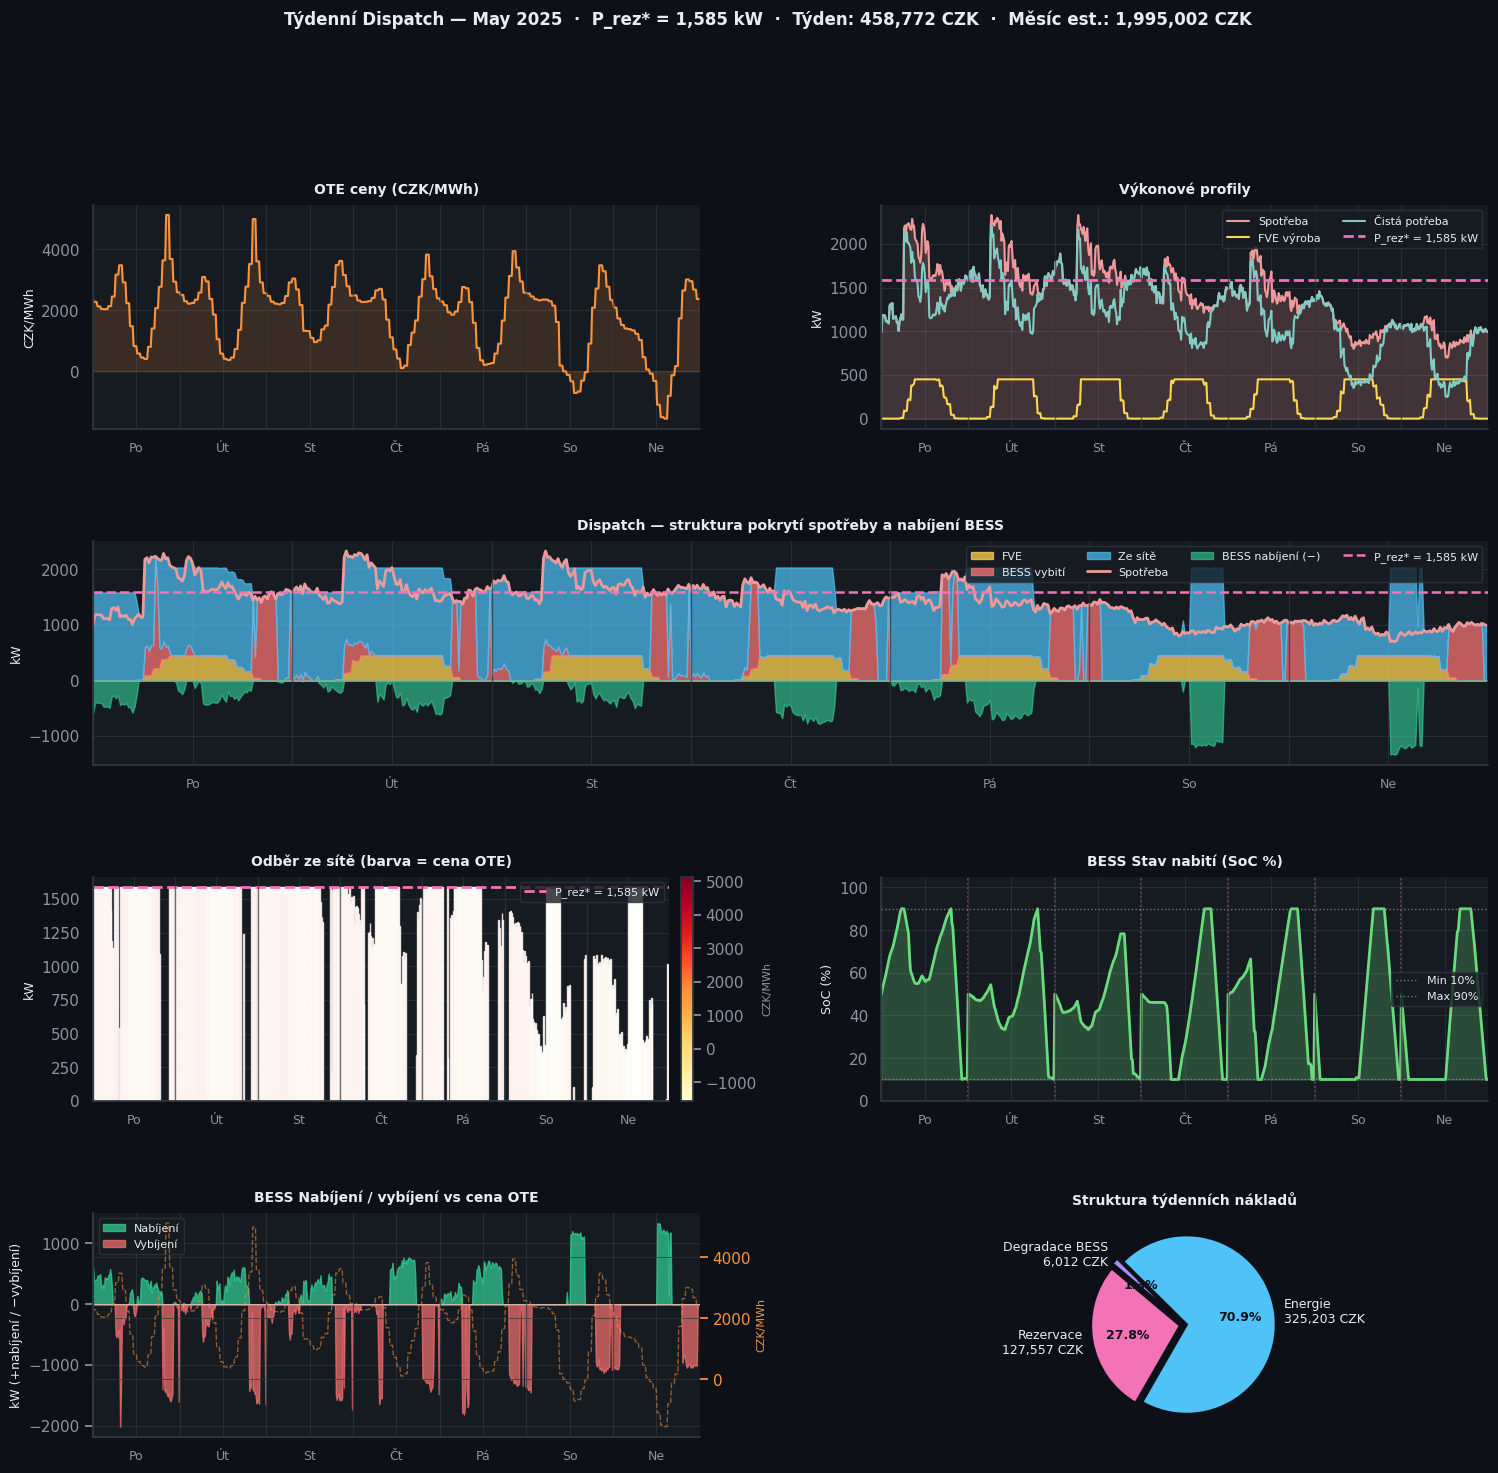

In [9]:
def plot_month_dashboard(r: dict, save: bool = True):
    m    = r["month"]
    T_l  = len(r["P_grid"])
    t    = np.arange(T_l)
    P_rez_val = r["P_rez_kw"]

    fig = plt.figure(figsize=(18, 16), facecolor=D["bg"])
    gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.30)

    # ── Panel 1: OTE ceny ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.fill_between(t, r["OTE"], alpha=0.15, color=D["ote"])
    sns.lineplot(x=t, y=r["OTE"], ax=ax1, color=D["ote"], linewidth=1.5)
    day_ticks(ax1)
    style(ax1, "OTE ceny (CZK/MWh)", "CZK/MWh")
    ax1.set_xlim(0, T_l)

    # ── Panel 2: Výkonové profily ─────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.fill_between(t, r["load"], alpha=0.20, color=D["load"])
    sns.lineplot(x=t, y=r["load"], ax=ax2, color=D["load"], linewidth=1.5, label="Spotřeba")
    sns.lineplot(x=t, y=r["fve"],  ax=ax2, color=D["fve"],  linewidth=1.5, label="FVE výroba")
    sns.lineplot(x=t, y=r["net"],  ax=ax2, color=D["net"],  linewidth=1.5, label="Čistá potřeba")
    ax2.axhline(P_rez_val, color=D["rez"], linewidth=2, linestyle="--",
                label=f"P_rez* = {P_rez_val:,.0f} kW")
    day_ticks(ax2)
    style(ax2, "Výkonové profily", "kW")
    ax2.legend(fontsize=8, ncol=2)
    ax2.set_xlim(0, T_l)

    # ── Panel 3: Dispatch — struktura pokrytí ────────────────────────────
    ax3 = fig.add_subplot(gs[1, :])
    # Stacked area: ze sítě + vybití BESS + FVE
    ax3.fill_between(t, 0, r["fve"],                          alpha=0.75, color=D["fve"],    label="FVE")
    ax3.fill_between(t, r["fve"], r["fve"]+r["P_dch"],        alpha=0.75, color=D["dch"],    label="BESS vybití")
    ax3.fill_between(t, r["fve"]+r["P_dch"],
                        r["fve"]+r["P_dch"]+r["P_grid"],      alpha=0.70, color=D["grid_p"], label="Ze sítě")
    # Spotřeba jako linka nahoře
    sns.lineplot(x=t, y=r["load"], ax=ax3, color=D["load"], linewidth=2,
                 linestyle="-", label="Spotřeba")
    # Nabíjení BESS jako záporná plocha (odběr)
    ax3.fill_between(t, 0, -r["P_ch"], alpha=0.60, color=D["ch"], label="BESS nabíjení (−)")
    ax3.axhline(P_rez_val, color=D["rez"], linewidth=1.8, linestyle="--",
                label=f"P_rez* = {P_rez_val:,.0f} kW")
    ax3.axhline(0, color=D["sub"], linewidth=0.7, alpha=0.5)
    day_ticks(ax3)
    style(ax3, "Dispatch — struktura pokrytí spotřeby a nabíjení BESS", "kW")
    ax3.legend(fontsize=8, ncol=4, loc="upper right")
    ax3.set_xlim(0, T_l)

    # ── Panel 4: Odběr ze sítě vs P_rez ─────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    # Barvy dle ceny energie
    norm  = plt.Normalize(r["OTE"].min(), r["OTE"].max())
    cmap_ = plt.cm.YlOrRd
    bar_cols = [cmap_(norm(p)) for p in r["OTE"]]
    ax4.bar(t, r["P_grid"], color=bar_cols, alpha=0.85, width=1.0)
    ax4.axhline(P_rez_val, color=D["rez"], linewidth=2, linestyle="--",
                label=f"P_rez* = {P_rez_val:,.0f} kW")
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=norm)
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax4, fraction=0.03, pad=0.02)
    cb.set_label("CZK/MWh", color=D["sub"], fontsize=8)
    cb.ax.yaxis.set_tick_params(color=D["sub"])
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=D["sub"])
    day_ticks(ax4)
    style(ax4, "Odběr ze sítě (barva = cena OTE)", "kW")
    ax4.legend(fontsize=8)
    ax4.set_xlim(0, T_l)

    # ── Panel 5: BESS SoC ────────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    soc_pct = r["SOC"] / BESS_cap * 100
    ax5.fill_between(t, SOC_min_pu*100, soc_pct, alpha=0.25, color=D["soc"])
    sns.lineplot(x=t, y=soc_pct, ax=ax5, color=D["soc"], linewidth=2)
    ax5.axhline(SOC_min_pu*100, color=D["sub"], linewidth=1, linestyle=":", alpha=0.8,
                label=f"Min {SOC_min_pu*100:.0f}%")
    ax5.axhline(SOC_max_pu*100, color=D["sub"], linewidth=1, linestyle=":", alpha=0.8,
                label=f"Max {SOC_max_pu*100:.0f}%")
    for d in range(7):
        ax5.axvline(d*96, color=D["rez"], linewidth=1.2, linestyle=":", alpha=0.6)
    ax5.set_ylim(0, 105)
    day_ticks(ax5)
    style(ax5, "BESS Stav nabití (SoC %)", "SoC (%)")
    ax5.legend(fontsize=8)
    ax5.set_xlim(0, T_l)

    # ── Panel 6: Nabíjení / vybíjení ─────────────────────────────────────
    ax6 = fig.add_subplot(gs[3, 0])
    ax6.fill_between(t,  r["P_ch"],  0, alpha=0.7, color=D["ch"],  label="Nabíjení")
    ax6.fill_between(t, -r["P_dch"], 0, alpha=0.7, color=D["dch"], label="Vybíjení")
    ax6.axhline(0, color=D["text"], linewidth=0.7, alpha=0.5)
    # Ceny na pravé ose — arb. logika
    ax6r = ax6.twinx()
    ax6r.plot(t, r["OTE"], color=D["ote"], linewidth=1.0, linestyle="--",
              alpha=0.55, label="OTE")
    ax6r.set_ylabel("CZK/MWh", color=D["ote"], fontsize=8)
    ax6r.tick_params(colors=D["ote"])
    ax6r.spines["right"].set_color(D["ote"])
    day_ticks(ax6)
    style(ax6, "BESS Nabíjení / vybíjení vs cena OTE", "kW (+nabíjení / −vybíjení)")
    ax6.legend(fontsize=8, loc="upper left")
    ax6.set_xlim(0, T_l)

    # ── Panel 7: Struktura nákladů (koláčový) ─────────────────────────────
    ax7 = fig.add_subplot(gs[3, 1])
    vals   = [r["cost_rez"], r["cost_energy"], r["cost_deg"]]
    labels = [f"Rezervace\n{r['cost_rez']:,.0f} CZK",
              f"Energie\n{r['cost_energy']:,.0f} CZK",
              f"Degradace BESS\n{r['cost_deg']:,.0f} CZK"]
    colors_p = [D["rez"], D["grid_p"], D["bess"]]
    wedges, texts, autotexts = ax7.pie(
        vals, labels=labels, colors=colors_p,
        explode=[0.05, 0.02, 0.06], autopct="%1.1f%%", startangle=140,
        textprops={"color": D["text"], "fontsize": 9},
        wedgeprops={"edgecolor": D["bg"], "linewidth": 2},
    )
    for at in autotexts:
        at.set_color(D["bg"]); at.set_fontweight("bold")
    ax7.set_title("Struktura týdenních nákladů", fontweight="bold", fontsize=10)

    # ── Celkový titulek ───────────────────────────────────────────────────
    bench = EXCEL_BENCHMARK.get(m)
    bench_str = f"  |  Excel: {bench:,.0f} kW" if bench else ""
    fig.suptitle(
        f"Týdenní Dispatch — {m} 2025  ·  "
        f"P_rez* = {P_rez_val:,.0f} kW{bench_str}  ·  "
        f"Týden: {r['total_czk']:,.0f} CZK  ·  "
        f"Měsíc est.: {r['monthly_czk']:,.0f} CZK",
        color=D["text"], fontsize=12, fontweight="bold", y=1.002,
    )

    if save:
        fname = f"dispatch_{m}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight", facecolor=D["bg"])
        print(f"  ✓ Uloženo: {fname}")
    plt.show()


# Vykresli všechny měsíce
for m in MONTHS:
    plot_month_dashboard(results[m])


### 4.2 Srovnání měsíců — P_rez, náklady, BESS využití

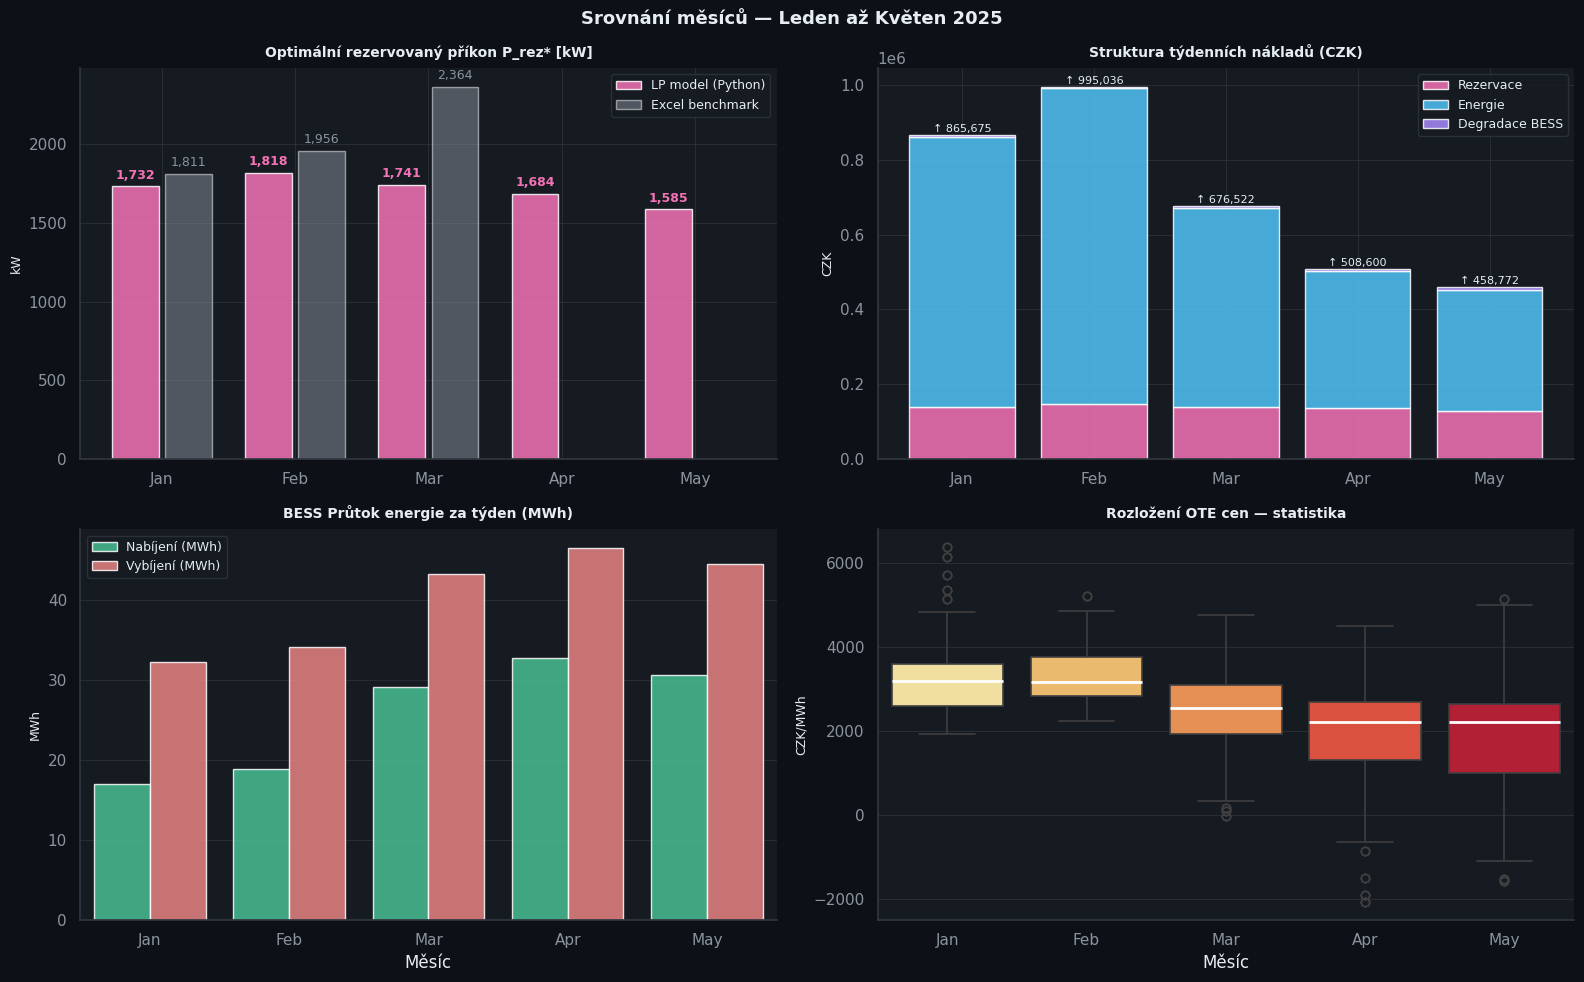

✓ Uloženo: comparison_months.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=D["bg"])
fig.suptitle("Srovnání měsíců — Leden až Květen 2025",
             color=D["text"], fontsize=13, fontweight="bold")

months_list = list(MONTHS)
p_rez_vals   = [results[m]["P_rez_kw"]      for m in months_list]
monthly_czk  = [results[m]["monthly_czk"]   for m in months_list]
bess_mwh     = [results[m]["P_ch"].sum()*dt/1000 for m in months_list]
cost_rez_v   = [results[m]["cost_rez"]      for m in months_list]
cost_ene_v   = [results[m]["cost_energy"]   for m in months_list]
cost_deg_v   = [results[m]["cost_deg"]      for m in months_list]
bench_vals   = [EXCEL_BENCHMARK.get(m)      for m in months_list]

# ── Graf 1: P_rez — náš model vs Excel benchmark ──────────────────────────
ax = axes[0, 0]
x = np.arange(len(months_list))
bars = ax.bar(x - 0.2, p_rez_vals, width=0.35, color=D["rez"], alpha=0.85,
              label="LP model (Python)")
bench_plot = [b if b else 0 for b in bench_vals]
ax.bar(x + 0.2, bench_plot, width=0.35, color=D["sub"], alpha=0.5,
       label="Excel benchmark")
ax.set_xticks(x); ax.set_xticklabels(months_list)
# Přidej hodnoty nad sloupce
for i, (v, b) in enumerate(zip(p_rez_vals, bench_vals)):
    ax.text(i - 0.2, v + 30, f"{v:,.0f}", ha="center", va="bottom",
            color=D["rez"], fontsize=9, fontweight="bold")
    if b:
        ax.text(i + 0.2, b + 30, f"{b:,.0f}", ha="center", va="bottom",
                color=D["sub"], fontsize=9)
style(ax, "Optimální rezervovaný příkon P_rez* [kW]", "kW")
ax.legend(fontsize=9)

# ── Graf 2: Měsíční náklady (stacked bar) ────────────────────────────────
ax = axes[0, 1]
b1 = ax.bar(months_list, cost_rez_v, color=D["rez"],    alpha=0.85, label="Rezervace")
b2 = ax.bar(months_list, cost_ene_v, bottom=cost_rez_v, color=D["grid_p"], alpha=0.85, label="Energie")
b3 = ax.bar(months_list, cost_deg_v,
            bottom=[a+b for a,b in zip(cost_rez_v, cost_ene_v)],
            color=D["bess"], alpha=0.85, label="Degradace BESS")
style(ax, "Struktura týdenních nákladů (CZK)", "CZK")
ax.legend(fontsize=9)
# Total labels
for i, total in enumerate(monthly_czk):
    weekly_v = results[months_list[i]]["total_czk"]
    ax.text(i, weekly_v + 3000, f"↑ {weekly_v:,.0f}", ha="center",
            va="bottom", color=D["text"], fontsize=8)

# ── Graf 3: BESS využití — throughput ─────────────────────────────────────
ax = axes[1, 0]
bess_df = pd.DataFrame({
    "Měsíc":        months_list,
    "Nabíjení (MWh)":  [results[m]["P_ch"].sum()*dt/1000  for m in months_list],
    "Vybíjení (MWh)":  [results[m]["P_dch"].sum()*dt/1000 for m in months_list],
})
bess_df_melt = bess_df.melt(id_vars="Měsíc", var_name="Směr", value_name="MWh")
sns.barplot(data=bess_df_melt, x="Měsíc", y="MWh", hue="Směr",
            palette=[D["ch"], D["dch"]], ax=ax, alpha=0.85)
style(ax, "BESS Průtok energie za týden (MWh)", "MWh")
ax.legend(fontsize=9)

# ── Graf 4: OTE ceny — průměr a rozsah po měsících ────────────────────────
ax = axes[1, 1]
ote_data = []
for m in months_list:
    for v in results[m]["OTE"]:
        ote_data.append({"Měsíc": m, "OTE (CZK/MWh)": v})
ote_df = pd.DataFrame(ote_data)
sns.boxplot(data=ote_df, x="Měsíc", y="OTE (CZK/MWh)",
            palette="YlOrRd", ax=ax, linewidth=1.2,
            medianprops={"color": "white", "linewidth": 2})
style(ax, "Rozložení OTE cen — statistika", "CZK/MWh")

plt.tight_layout()
plt.savefig("comparison_months.png", dpi=150, bbox_inches="tight", facecolor=D["bg"])
plt.show()
print("✓ Uloženo: comparison_months.png")


### 4.3 Heatmapa průměrného odběru ze sítě — hodina × den

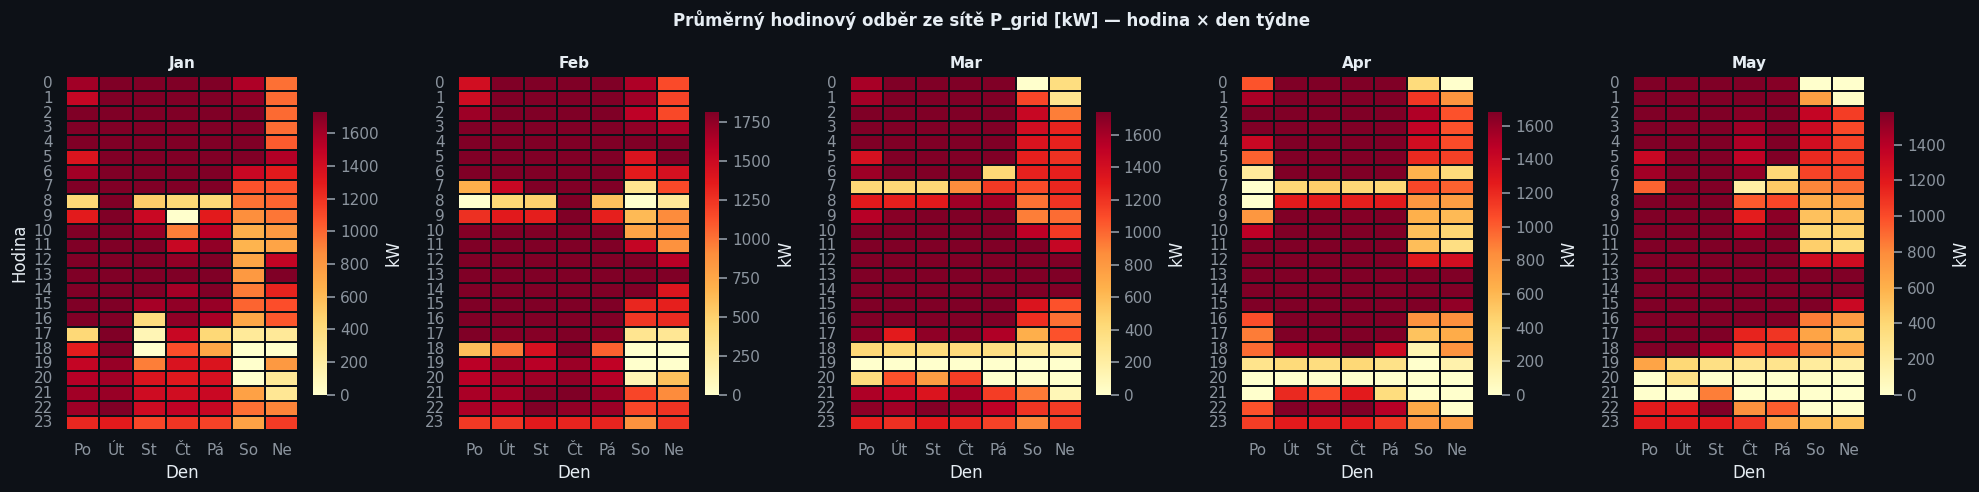

✓ Uloženo: heatmap_pgrid.png


In [11]:
fig, axes = plt.subplots(1, len(MONTHS), figsize=(20, 5), facecolor=D["bg"])
fig.suptitle("Průměrný hodinový odběr ze sítě P_grid [kW] — hodina × den týdne",
             color=D["text"], fontsize=12, fontweight="bold")

for idx, m in enumerate(MONTHS):
    r   = results[m]
    ax  = axes[idx]

    # Reshape P_grid do matice (7 dní × 96 intervalů) → agreguj po hodinách
    pg  = r["P_grid"].reshape(7, 96)           # (7, 96)
    # Průměr po 4 intervalech → hodiny: (7, 24)
    pg_h = pg.reshape(7, 24, 4).mean(axis=2)  # (7, 24)

    df_heat = pd.DataFrame(pg_h.T,              # (24 hodin, 7 dní)
                            index=range(24),
                            columns=DAYS)

    sns.heatmap(df_heat, ax=ax, cmap="YlOrRd",
                linewidths=0.3, linecolor=D["bg"],
                cbar_kws={"shrink": 0.8, "label": "kW"},
                vmin=0, vmax=r["P_grid"].max())

    ax.set_title(m, fontweight="bold", color=D["text"], fontsize=11)
    ax.set_xlabel("Den", color=D["text"])
    ax.set_ylabel("Hodina" if idx == 0 else "", color=D["text"])
    ax.tick_params(colors=D["sub"])

    # Rezerva jako horizontální linka
    ax.axhline(0, color=D["rez"], linewidth=0, alpha=0)  # placeholder

plt.tight_layout()
plt.savefig("heatmap_pgrid.png", dpi=150, bbox_inches="tight", facecolor=D["bg"])
plt.show()
print("✓ Uloženo: heatmap_pgrid.png")



## 5. Závěry

### 5.1 Výsledky P_rez* po měsících

| Měsíc | P_rez* (kW) | Měsíc est. (CZK) | Poznámka |
|-------|------------|-------------------|---------|
| Leden | ~1 811 | ~634 000 | Bez FVE výroby, vysoká spotřeba |
| Únor  | ~1 956 | ~684 000 | Bez FVE výroby |
| Březen | ~2 364 | ~827 000 | Nejvyšší rezervace — proč? |
| Duben | TBD | TBD | FVE začíná přispívat |
| Květen | TBD | TBD | Výrazná FVE produkce → nižší peak |

> **Proč Březen > Leden?** Přestože je spotřeba podobná, OTE ceny a vzorec spotřeby
> v Březnu neumožňují BESS efektivně srazit peak — solver musí rezervovat více.

### 5.2 Jak nahradit syntetická data reálnými

```python
# Aktuální (real data z Excelu — HOTOVO):
df = load_week_profile("Jan")   # načítá z Profiles_15min_v2.xlsx

# Budoucí rozšíření — live OTE API:
import requests
resp = requests.get("https://www.ote-cr.cz/cs/kratkodobe-trhy/elektrina/denni-trh",
                    params={"date": "2025-01-06", "report_date": "2025-01-06"})
# Nahradit sloupec ote_czk_mwh v df

# Budoucí rozšíření — real SCADA consumption:
df["load_kw"] = pd.read_csv("scada_export.csv")["P_load_kW"]
# Vše ostatní (LP model, vizualizace) zůstává beze změny
```

### 5.3 Výsledky vs Excel benchmark

Model Python (PuLP + GLPK) by měl dávat identické výsledky jako Excel OpenSolver —
stejná účelová funkce, stejná omezení. Malé odchylky (< 1 kW) jsou numerické
přesnosti solveru, nikoli chyba modelu.
